In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/finalapi.csv')

print(f"Original shape: {df.shape}")

# Step 1: Remove 2015 (partial year — distorts time-series)
df = df[df['STAT_PROFILE_DATE_YEAR'] != 2015]
print(f"After removing 2015: {df.shape}")

# Step 2: Remove negative premiums (cancellations/reversals)
df = df[df['WRTN_PREM_AMT'] > 0]
print(f"After removing negatives: {df.shape}")

# Step 3: Replace 99999 sentinel values with NaN
sentinel_cols = ['GROWTH_RATE_3YR', 'LOSS_RATIO', 'LOSS_RATIO_3YR', 'RETENTION_RATIO']
for col in sentinel_cols:
    count = (df[col] == 99999).sum()
    df[col] = df[col].replace(99999, np.nan)
    print(f"{col}: replaced {count} sentinel values with NaN")

Original shape: (213328, 49)
After removing 2015: (192347, 49)
After removing negatives: (147760, 49)
GROWTH_RATE_3YR: replaced 50546 sentinel values with NaN
LOSS_RATIO: replaced 0 sentinel values with NaN
LOSS_RATIO_3YR: replaced 16209 sentinel values with NaN
RETENTION_RATIO: replaced 88984 sentinel values with NaN


In [2]:
# Check nulls after sentinel replacement
print("Nulls after sentinel replacement:")
print(df[sentinel_cols].isnull().sum())

# Fill with median (robust to outliers for financial ratios)
for col in sentinel_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled NaN with median = {median_val:.4f}")

print(f"\nFinal nulls: {df.isnull().sum().sum()}")

Nulls after sentinel replacement:
GROWTH_RATE_3YR    50546
LOSS_RATIO             0
LOSS_RATIO_3YR     16209
RETENTION_RATIO    88984
dtype: int64
GROWTH_RATE_3YR: filled NaN with median = -0.0156
LOSS_RATIO: filled NaN with median = 0.0000
LOSS_RATIO_3YR: filled NaN with median = 0.4243
RETENTION_RATIO: filled NaN with median = 0.8875

Final nulls: 0


In [3]:
# Create time-based features from year
df['AGENCY_AGE'] = df['STAT_PROFILE_DATE_YEAR'] - df['AGENCY_APPOINTMENT_YEAR']

# Premium growth YoY per record
df['PREMIUM_GROWTH_YOY'] = (df['WRTN_PREM_AMT'] - df['PREV_WRTN_PREM_AMT']) / \
                            (df['PREV_WRTN_PREM_AMT'].replace(0, np.nan))
df['PREMIUM_GROWTH_YOY'] = df['PREMIUM_GROWTH_YOY'].fillna(0).clip(-1, 10)

# Log transform target variable
df['LOG_WRTN_PREM_AMT'] = np.log1p(df['WRTN_PREM_AMT'])

# Encode categorical columns
df['PROD_LINE_ENC'] = df['PROD_LINE'].map({'CL': 0, 'PL': 1})
df['STATE_ENC'] = df['STATE_ABBR'].astype('category').cat.codes

print("New features created:")
print(df[['AGENCY_AGE', 'PREMIUM_GROWTH_YOY', 'LOG_WRTN_PREM_AMT', 
          'PROD_LINE_ENC', 'STATE_ENC']].head())

New features created:
   AGENCY_AGE  PREMIUM_GROWTH_YOY  LOG_WRTN_PREM_AMT  PROD_LINE_ENC  STATE_ENC
0          48           10.000000           8.031265              0          0
1          49            0.206623           8.789246              0          0
2          50           -0.054428           8.733290              0          0
3          51           -0.168445           8.548864              0          0
4          52           -0.122518           8.418192              0          0


In [4]:
# Final feature set for modeling
# NOTE: Excluding PRD_ERND_PREM_AMT — perfect correlation = data leakage
feature_cols = [
    'AGENCY_ID',                    # ← add this
    'STAT_PROFILE_DATE_YEAR',
    'POLY_INFORCE_QTY',
    'NB_WRTN_PREM_AMT',
    'PRD_INCRD_LOSSES_AMT',
    'RETENTION_RATIO',
    'LOSS_RATIO',
    'GROWTH_RATE_3YR',
    'ACTIVE_PRODUCERS',
    'AGENCY_AGE',
    'PREMIUM_GROWTH_YOY',
    'PROD_LINE_ENC',
    'STATE_ENC',
    'MONTHS'
]

target_col = 'LOG_WRTN_PREM_AMT'  # log-transformed target
target_raw = 'WRTN_PREM_AMT'      # raw target for inverse transform later

df_model = df[feature_cols + [target_col, target_raw]].copy()

print(f"Modeling dataset shape: {df_model.shape}")
print(f"\nFeature summary:")
print(df_model.describe().round(2))

# Save cleaned data
df_model.to_csv('../data/processed/insurance_cleaned.csv', index=False)
print("\n✅ Cleaned data saved to data/processed/insurance_cleaned.csv")

Modeling dataset shape: (147760, 16)

Feature summary:
       AGENCY_ID  STAT_PROFILE_DATE_YEAR  POLY_INFORCE_QTY  NB_WRTN_PREM_AMT  \
count  147760.00               147760.00         147760.00         147760.00   
mean     4984.36                 2009.64            225.75           3083.67   
std      2924.26                    2.84            912.62          11709.93   
min         3.00                 2005.00              0.00              0.00   
25%      2379.00                 2007.00              0.00              0.00   
50%      4978.00                 2010.00              0.00              0.00   
75%      7589.00                 2012.00             43.00           1183.00   
max      9998.00                 2014.00          22968.00         556930.22   

       PRD_INCRD_LOSSES_AMT  RETENTION_RATIO  LOSS_RATIO  GROWTH_RATE_3YR  \
count             147760.00        147760.00   147760.00        147760.00   
mean               15093.55             0.87        0.64             0

In [5]:
from sklearn.model_selection import train_test_split

X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTarget variable stats (log scale):")
print(y_train.describe().round(4))

# Save splits
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
print("\n✅ Train/test splits saved")

Training set: (118208, 14)
Test set:     (29552, 14)

Target variable stats (log scale):
count    118208.0000
mean          8.1089
std           2.1878
min           0.0000
25%           6.5530
50%           8.0050
75%           9.6351
max          14.3554
Name: LOG_WRTN_PREM_AMT, dtype: float64

✅ Train/test splits saved


In [6]:
# Fix ACTIVE_PRODUCERS sentinel
df_model['ACTIVE_PRODUCERS'] = df_model['ACTIVE_PRODUCERS'].replace(99999, np.nan)
df_model['ACTIVE_PRODUCERS'] = df_model['ACTIVE_PRODUCERS'].fillna(
    df_model['ACTIVE_PRODUCERS'].median()
)

# Fix AGENCY_AGE — negative values caused by sentinel AGENCY_APPOINTMENT_YEAR
df_model['AGENCY_AGE'] = df_model['AGENCY_AGE'].clip(lower=0, upper=100)

print("ACTIVE_PRODUCERS max:", df_model['ACTIVE_PRODUCERS'].max())
print("AGENCY_AGE range:", df_model['AGENCY_AGE'].min(), "to", df_model['AGENCY_AGE'].max())
print("✅ Sentinels fixed")

ACTIVE_PRODUCERS max: 301.0
AGENCY_AGE range: 0 to 79
✅ Sentinels fixed


In [7]:
from sklearn.model_selection import train_test_split

# Overwrite cleaned file with fixed version
df_model.to_csv('../data/processed/insurance_cleaned.csv', index=False)

X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Overwrite splits
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print("✅ Cleaned data re-saved")

Training set: (118208, 14)
Test set:     (29552, 14)
✅ Cleaned data re-saved


In [8]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn'], capture_output=True)
subprocess.run(['pip', 'install', 'prophet'], capture_output=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ All libraries loaded")

✅ All libraries loaded


In [9]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (118208, 14)
X_test:  (29552, 14)
y_train: (118208,)
y_test:  (29552,)


In [10]:
# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("=== Model 1: Linear Regression ===")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

=== Model 1: Linear Regression ===
MAE  : 1.4700
RMSE : 1.8304
R²   : 0.3086


In [11]:
# Train (n_estimators=100, this may take 1-2 minutes)
print("Training Random Forest... please wait")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("=== Model 2: Random Forest Regressor ===")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Training Random Forest... please wait
=== Model 2: Random Forest Regressor ===
MAE  : 0.4950
RMSE : 0.8449
R²   : 0.8527


In [12]:
from prophet import Prophet

# Prophet requires specific format: ds (date) and y (target)
df_clean = pd.read_csv('../data/processed/insurance_cleaned.csv')

# Aggregate total premium by year for Prophet
prophet_df = df_clean.groupby('STAT_PROFILE_DATE_YEAR')['WRTN_PREM_AMT'].sum().reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'], format='%Y')

print("Prophet input data:")
print(prophet_df)

# Train on first 8 years (2005-2012), forecast last 2 (2013-2014)
train_prophet = prophet_df[prophet_df['ds'] <= '2012-01-01']
test_prophet  = prophet_df[prophet_df['ds'] >  '2012-01-01']

# Fit model
prophet_model = Prophet(yearly_seasonality=True, 
                        changepoint_prior_scale=0.05)
prophet_model.fit(train_prophet)

# Forecast
future = prophet_model.make_future_dataframe(periods=2, freq='YS')
forecast = prophet_model.predict(future)

# Extract predictions for test years
prophet_pred = forecast[forecast['ds'] > '2012-01-01'][['ds', 'yhat']].reset_index(drop=True)
prophet_actual = test_prophet['y'].values
prophet_predicted = prophet_pred['yhat'].values

# Evaluate
p_mae  = mean_absolute_error(prophet_actual, prophet_predicted)
p_rmse = np.sqrt(mean_squared_error(prophet_actual, prophet_predicted))
p_r2   = r2_score(prophet_actual, prophet_predicted)

print("\n=== Model 3: Facebook Prophet ===")
print(f"MAE  : {p_mae:,.2f}")
print(f"RMSE : {p_rmse:,.2f}")
print(f"R²   : {p_r2:.4f}")

Importing plotly failed. Interactive plots will not work.


Prophet input data:
          ds             y
0 2005-01-01  2.748479e+08
1 2006-01-01  4.134106e+08
2 2007-01-01  4.090166e+08
3 2008-01-01  4.158240e+08
4 2009-01-01  4.133547e+08
5 2010-01-01  4.108110e+08
6 2011-01-01  4.023776e+08
7 2012-01-01  4.059678e+08
8 2013-01-01  4.272815e+08
9 2014-01-01  4.375439e+08


11:03:42 - cmdstanpy - INFO - Chain [1] start processing
11:03:43 - cmdstanpy - INFO - Chain [1] done processing



=== Model 3: Facebook Prophet ===
MAE  : 14,416,640.13
RMSE : 15,642,870.80
R²   : -8.2939


In [13]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Facebook Prophet'],
    'MAE':   [lr_mae, rf_mae, p_mae],
    'RMSE':  [lr_rmse, rf_rmse, p_rmse],
    'R²':    [lr_r2, rf_r2, p_r2]
})

print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))

# Save for report
results.to_csv('../data/processed/model_comparison.csv', index=False)
print("\n✅ Model comparison saved")

=== MODEL COMPARISON ===
            Model          MAE         RMSE        R²
Linear Regression 1.469974e+00 1.830372e+00  0.308636
    Random Forest 4.949623e-01 8.449417e-01  0.852673
 Facebook Prophet 1.441664e+07 1.564287e+07 -8.293852

✅ Model comparison saved


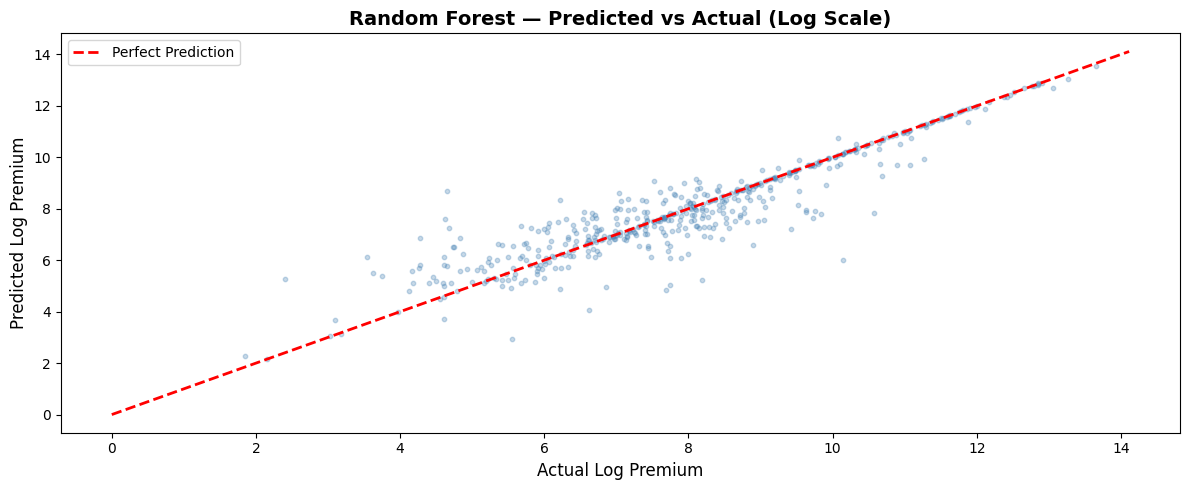

In [14]:
plt.figure(figsize=(12, 5))
plt.scatter(y_test[:500], rf_pred[:500], alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Random Forest — Predicted vs Actual (Log Scale)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Actual Log Premium', fontsize=12)
plt.ylabel('Predicted Log Premium', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/fig_5_7_rf_predicted_vs_actual.png', dpi=150)
plt.show()

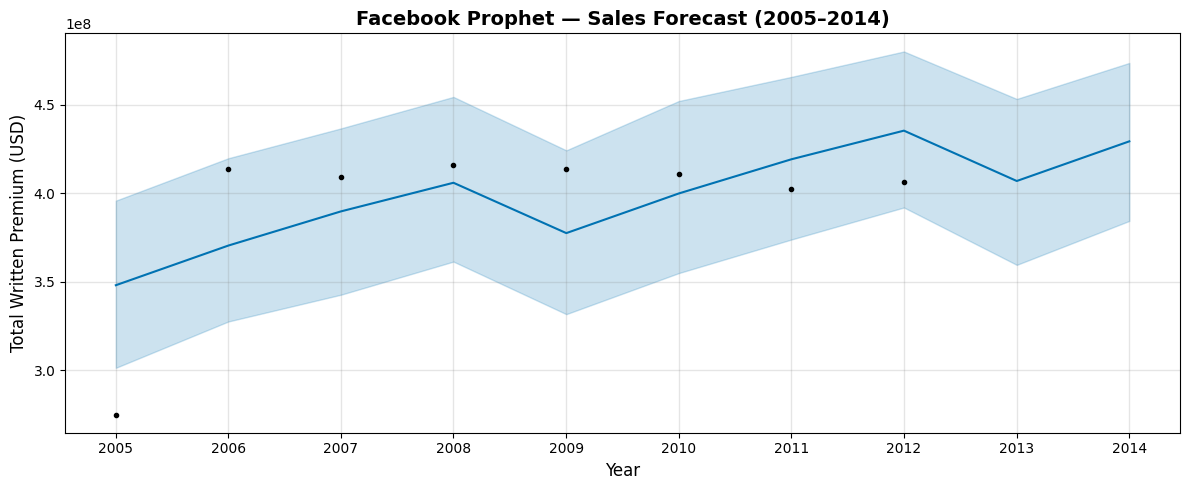

In [15]:
fig = prophet_model.plot(forecast, figsize=(12, 5))
plt.title('Facebook Prophet — Sales Forecast (2005–2014)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Written Premium (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/fig_5_8_prophet_forecast.png', dpi=150)
plt.show()

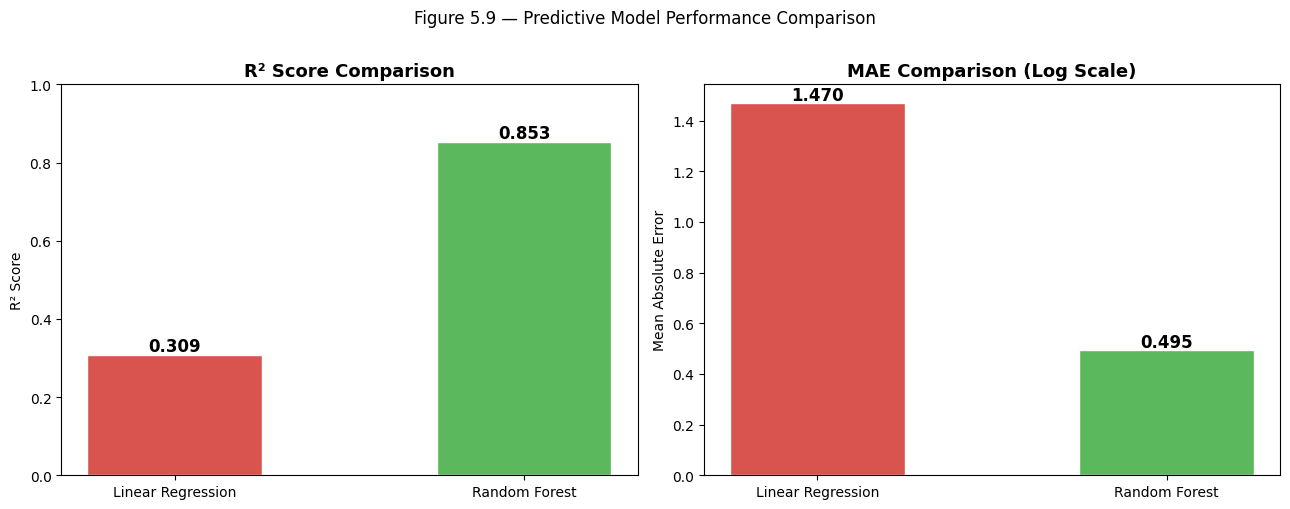

In [16]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_r2, rf_r2]
mae_scores = [lr_mae, rf_mae]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# R² comparison
bars1 = axes[0].bar(models, r2_scores, color=['#d9534f', '#5cb85c'], 
                     edgecolor='white', width=0.5)
axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

# MAE comparison
bars2 = axes[1].bar(models, mae_scores, color=['#d9534f', '#5cb85c'],
                     edgecolor='white', width=0.5)
axes[1].set_title('MAE Comparison (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error')
for bar, val in zip(bars2, mae_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Figure 5.9 — Predictive Model Performance Comparison', 
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_5_9_model_comparison.png', dpi=150)
plt.show()

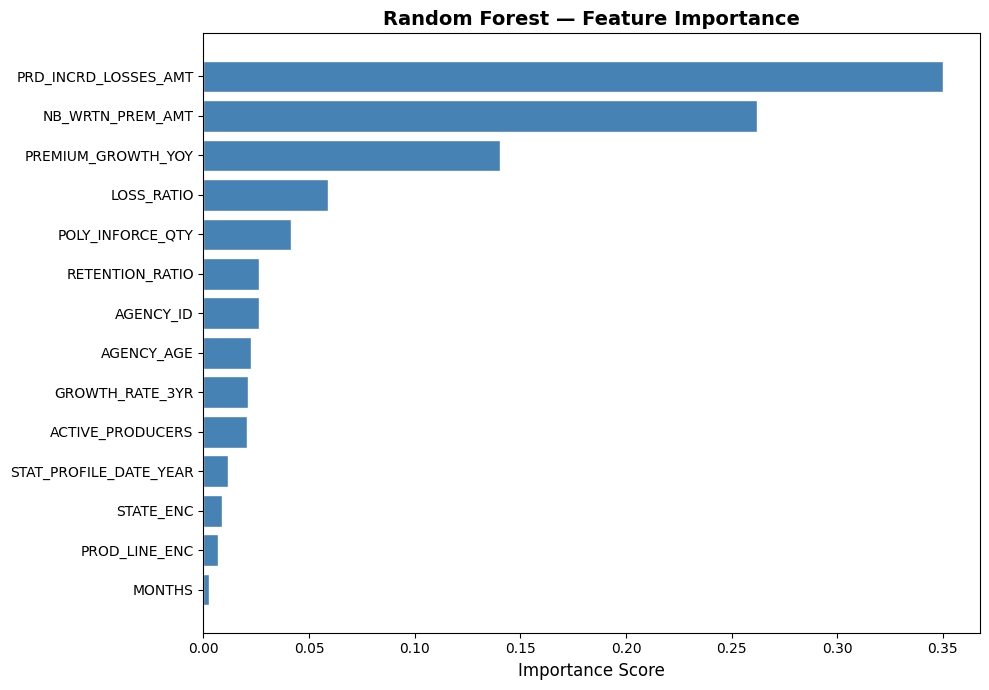


Top 5 most important features:
             Feature  Importance
PRD_INCRD_LOSSES_AMT    0.350086
    NB_WRTN_PREM_AMT    0.262198
  PREMIUM_GROWTH_YOY    0.140560
          LOSS_RATIO    0.058931
    POLY_INFORCE_QTY    0.041199


In [17]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(feature_importance['Feature'], 
                feature_importance['Importance'],
                color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/fig_5_10_feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 most important features:")
print(feature_importance.tail(5)[['Feature','Importance']].iloc[::-1].to_string(index=False))

In [19]:
#Export predictions for Power BI
predictions_df = pd.DataFrame({
    'Actual_Log_Premium': y_test.values,
    'Predicted_Log_Premium': rf_pred,
    'Actual_Premium': np.expm1(y_test.values),
    'Predicted_Premium': np.expm1(rf_pred)
})
predictions_df.to_csv('../data/processed/rf_predictions.csv', index=False)

#Prophet forecast - Export
forecast_export = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export.columns = ['Year', 'Forecast', 'Lower_Bound', 'Upper_Bound']
forecast_export.to_csv('../data/processed/prophet_forecast.csv', index=False)

#Model Comparison - Export
results.to_csv('../data/processed/model_comparison.csv', index=False)